# Project 3 - Image Classificaion
### Damian Franco
### Meiling Traeger

This project demonstrates an implementation of a model that should successfully classify plant seedling species based only on images. TensorFlow and Keras was the driving forces behind the design and implementation of our model and how we processed our images. We used a combination of feed-forward neural networks and convolutional neural networks as a basis for our model that we trained to classify these plant seedlings. There are sections for data loading, examination and pre-processing, as well as model training and testing sections.

In [1]:
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import os 
import sklearn as ski
import math
import scipy.stats as stats
from pprint import pprint
import dask
import dask.dataframe as dd
import zipfile
from google.colab import files
from scipy.stats import norm
from scipy.optimize import minimize
from glob import glob
import cv2
import tensorflow as tf
from mpl_toolkits.axes_grid1 import ImageGrid
import os
from keras.preprocessing import image
import keras.utils as imageUTIL

In [2]:
# Comment in if wanting to load data directly from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Data

## References:
* https://pypi.org/project/opencv-python/ 
* https://www.quora.com/How-can-I-read-multiple-images-in-Python-presented-in-a-folder
* https://www.geeksforgeeks.org/how-to-iterate-through-images-in-a-folder-python/
* https://towardsdatascience.com/what-library-can-load-image-in-python-and-what-are-their-difference-d1628c6623ad
* https://machinelearningmastery.com/how-to-load-and-manipulate-images-for-deep-learning-in-python-with-pil-pillow/
* https://www.geeksforgeeks.org/opencv-python-tutorial/

In [ ]:
# Species classes set
species_list = ["Black-grass", "Charlock", "Cleavers", "Common Chickweed", "Common wheat", "Fat Hen",
                "Loose Silky-bent", "Maize", "Scentless Mayweed", "Shepherds Purse", "Small-flowered Cranesbill",
                "Sugar beet"]

In [5]:
# Set paths foor each data set and submission csv generation
SAMPLE_PER_CATEGORY = 200
SEED = 1987
data_dir = 'drive/My Drive/machineLearning/weeds/'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
sample_submission = pd.read_csv(os.path.join(data_dir, 'sample_submission.csv'))

In [6]:
# Print out number of content in all folders
for category in species_list:
    print('{} {} images'.format(category, len(os.listdir(os.path.join(train_dir, category)))))

Black-grass 263 images
Charlock 390 images
Cleavers 287 images
Common Chickweed 611 images
Common wheat 221 images
Fat Hen 475 images
Loose Silky-bent 654 images
Maize 221 images
Scentless Mayweed 516 images
Shepherds Purse 231 images
Small-flowered Cranesbill 496 images
Sugar beet 385 images


In [7]:
# Load in training set
train = []
for category_id, category in enumerate(species_list):
    for file in os.listdir(os.path.join(train_dir, category)):
        train.append(['train/{}/{}'.format(category, file), category_id, category])
train = pd.DataFrame(train, columns=['file', 'category_id', 'category'])

In [8]:
train.head(4)

,file,category_id,category
0,train/Black-grass/075d004bc.png,0,Black-grass
1,train/Black-grass/0183fdf68.png,0,Black-grass
2,train/Black-grass/0b228a6b8.png,0,Black-grass
3,train/Black-grass/0b3e7a7a9.png,0,Black-grass


In [10]:
# Parse and read all images with OpenCV
images_path = 'drive/My Drive/machineLearning/weeds/train/*/*.png'
images = glob(images_path)
train_images = []
train_labels = []

for img in images:
    train_images.append(cv2.resize(cv2.imread(img), (256, 256))) # Image is 256x256x3
    train_labels.append(img.split('/')[-2])
train_X = np.asarray(train_images)
train_Y = pd.DataFrame(train_labels)

In [11]:
train_Y.rename(columns={0:'species'},inplace=True)

In [12]:
train_X

array([[[[ 42,  51,  63],
         [ 42,  51,  63],
         [ 41,  51,  62],
         ...,
         [ 24,  38,  64],
         [ 26,  39,  65],
         [ 27,  40,  65]],

        [[ 42,  51,  63],
         [ 42,  51,  63],
         [ 41,  51,  62],
         ...,
         [ 24,  37,  63],
         [ 26,  39,  64],
         [ 27,  40,  64]],

        [[ 41,  52,  63],
         [ 41,  52,  63],
         [ 41,  52,  62],
         ...,
         [ 24,  36,  62],
         [ 26,  38,  63],
         [ 27,  39,  63]],

        ...,

        [[ 34,  46,  60],
         [ 34,  46,  60],
         [ 35,  47,  62],
         ...,
         [ 55,  68,  82],
         [ 60,  73,  85],
         [ 62,  75,  87]],

        [[ 35,  47,  61],
         [ 36,  48,  62],
         [ 37,  49,  64],
         ...,
         [ 57,  69,  83],
         [ 60,  72,  84],
         [ 61,  73,  85]],

        [[ 36,  48,  62],
         [ 36,  49,  63],
         [ 37,  50,  65],
         ...,
         [ 58,  70,  83],
        

In [13]:
train_Y

,species
0,Loose Silky-bent
1,Loose Silky-bent
2,Loose Silky-bent
3,Loose Silky-bent
4,Loose Silky-bent
...,...
4745,Small-flowered Cranesbill
4746,Small-flowered Cranesbill
4747,Small-flowered Cranesbill
4748,Small-flowered Cranesbill


# Examine Data

## References:
* https://towardsdatascience.com/image-data-analysis-using-python-edddfdf128f4
* https://datacarpentry.org/image-processing/aio/index.html
* https://www.kdnuggets.com/2018/09/image-data-analysis-python-p3.html

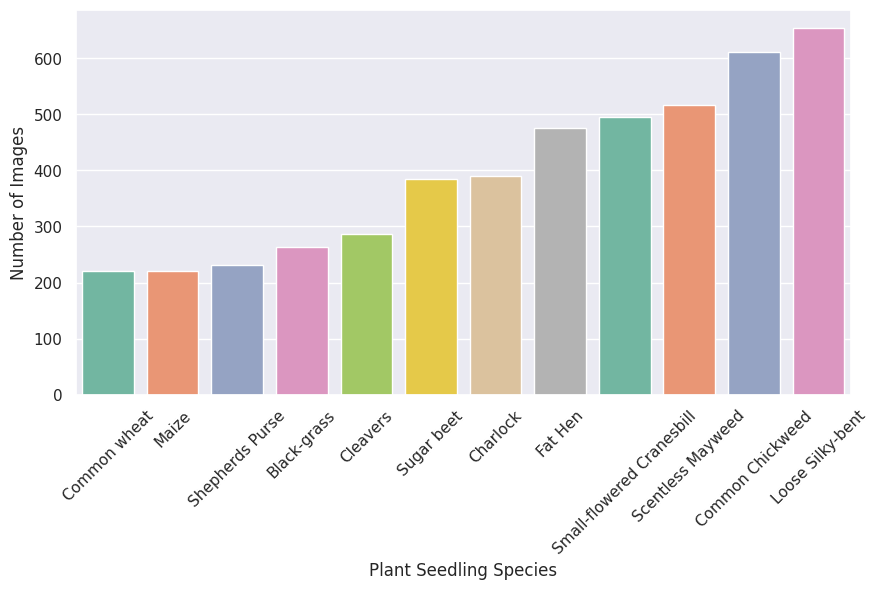

In [51]:

# Set the seaborn theme to a dark theme
sns.set_theme(style='darkgrid')

# Check out the distribution in our data
%matplotlib inline 
plt.figure(figsize=(10,5))

# Sort data by count of each category
sorted_data = train_Y.groupby('species').size().reset_index(name='count').sort_values('count')

chart = sns.barplot(
    data=sorted_data,
    x='species',
    y='count',
    palette='Set2'  
)

chart.set_xticklabels(chart.get_xticklabels(), rotation=45)
chart.set_xlabel("Plant Seedling Species")
chart.set_ylabel("Number of Images") 
plt.show()

In [15]:
# Reading in image path
def read_img(filepath, size):
    img = imageUTIL.load_img(os.path.join(data_dir, filepath), target_size=size)
    img = imageUTIL.img_to_array(img)
    return img

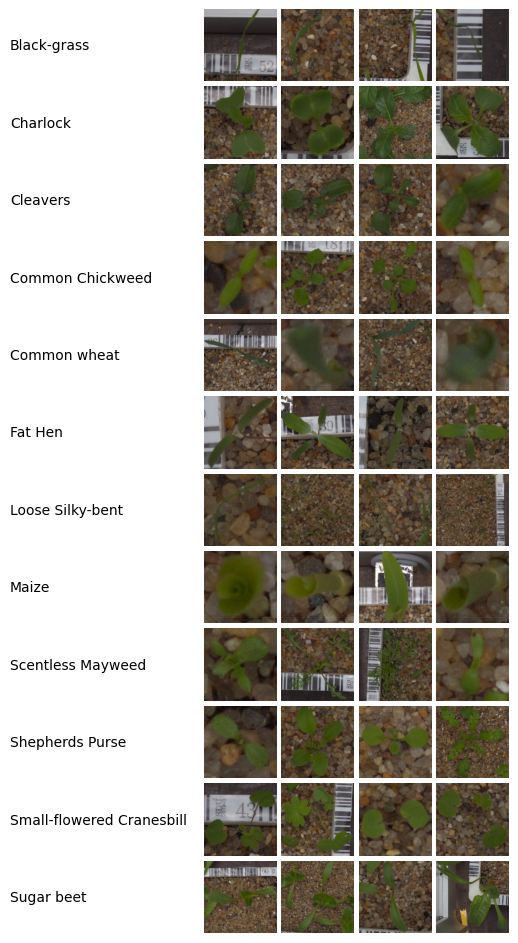

In [36]:
# Check out the comparison of each image of species to another
fig = plt.figure(1, figsize=(len(species_list), len(species_list)))
grid = ImageGrid(fig, 111, nrows_ncols=(len(species_list), 4), axes_pad=0.05)
i = 0
for category_id, category in enumerate(species_list):
    for filepath in train[train['category'] == category]['file'].values[:4]:
        ax = grid[i]
        img = read_img(filepath, (224, 224))
        ax.imshow(img / 255.)
        ax.axis('off')
        if i % 4 == 0:
            ax.text(-600, 112, filepath.split('/')[1], verticalalignment='center')
        i += 1
plt.show();

# Pre-processing Data

## References:
* https://keras.io/api/preprocessing/image/
* https://www.kdnuggets.com/2018/09/image-data-analysis-python-p3.html
* https://regenerativetoday.com/some-basic-image-preprocessing-operations-for-beginners-in-python/
* https://www.geeksforgeeks.org/image-processing-with-keras-in-python/
* https://towardsdatascience.com/image-classification-with-early-stopping-a-quick-tutorial-58d3d346184c
* https://machinelearningmastery.com/image-augmentation-deep-learning-keras/

In [19]:
# Defines callback layer for early stopping
def define_callbacks():
    save_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath='model.h5',
        monitor='val_acc',
        save_best_only=True,
        verbose=1
    )
    return save_callback

In [18]:
def define_generators():
    # Generate and pre-process training set from training.csv
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=360,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.5,
        vertical_flip=True,
        horizontal_flip=True,
        validation_split=0.2, # change to use validation instead of training on entire training set
    )

    # Generate training 80% set
    train_generator = train_datagen.flow_from_directory(
        directory='drive/My Drive/machineLearning/weeds/train',
        target_size=(width, height),
        batch_size=batch_size,
        color_mode='rgb',
        class_mode="categorical",
        subset='training',
    )

    # Generate validation 20% set
    validation_generator = train_datagen.flow_from_directory(
        directory='drive/My Drive/machineLearning/weeds/train',
        target_size=(width, height),
        batch_size=batch_size,
        color_mode='rgb',
        class_mode="categorical",
        subset='validation',
    )

    # Generate testing data set from test.csv
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator()
    test_generator = test_datagen.flow_from_directory(
        directory='drive/My Drive/machineLearning/weeds',
        classes=['test'],
        target_size=(width, height),
        batch_size=1,
        color_mode='rgb',
        shuffle=False,
        class_mode='categorical')

    return train_generator, validation_generator, test_generator

# NN Model Setup

## References:
* https://keras.io/
* https://www.analyticsvidhya.com/blog/2021/11/training-neural-network-with-keras-and-basics-of-deep-learning/
* https://towardsdatascience.com/building-our-first-neural-network-in-keras-bdc8abbc17f5
* https://carpentries-incubator.github.io/deep-learning-intro/02-keras/index.html
* https://www.tutorialspoint.com/keras/keras_deep_learning.htm 
* https://keras.io/api/optimizers/adam/
* https://www.educba.com/keras-optimizers/
* https://keras.io/api/layers/activations/
* https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/
* https://www.geeksforgeeks.org/softmax-regression-using-keras/
* https://keras.io/api/layers/regularizers/
* https://medium.com/data-science-365/how-to-apply-l1-and-l2-regularization-techniques-to-keras-models-da6249d8a469

In [21]:
# Defines our model
def define_model(width, height):
    # Input Layer
    model_input = tf.keras.layers.Input(shape=(width, height, 3), name='image_input')
    
    # ResNet NN layer
    model_main = tf.keras.applications.inception_resnet_v2.InceptionResNetV2(include_top=False, weights='imagenet')(model_input)

    # Flatten ResNet layer
    model_dense1 = tf.keras.layers.Flatten()(model_main)
    
    # Added a dense layer with L2 regularization with ReLU activation
    model_dense2 = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(model_dense1)
    
    # Output layer with softmax activation
    model_out = tf.keras.layers.Dense(12, activation="softmax")(model_dense2)
    model = tf.keras.models.Model(model_input,  model_out)

    # Define Adam optimizer
    # optimizer = tf.keras.optimizers.Adam(learning_rate=0.000085, beta_1=0.9, beta_2=0.999) # 62% validation settings
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.9, beta_2=0.999)  #Testing
    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

# Training

## References:
* https://machinelearningmastery.com/tutorial-first-neural-network-python-keras/
* https://www.activestate.com/resources/quick-reads/what-is-a-keras-model/
* https://www.tensorflow.org/guide/keras/train_and_evaluate
* https://www.geeksforgeeks.org/choose-optimal-number-of-epochs-to-train-a-neural-network-in-keras/
* https://www.atmosera.com/blog/building-neural-networks-with-keras-and-tensorflow/

In [20]:
# Set parameters for training model
# 1 epoch was 79%, 2 epochs is 90%
nb_epoch = 3
batch_size = 16
width = 299
height = 299

In [ ]:
# Intialize model
model = define_model(width, height)
model.summary()
train_generator, validation_generator, test_generator = define_generators()
save_callback = define_callbacks()

In [22]:
# Fit or train the model with the parameters set
model.fit(
    train_generator,
    epochs=nb_epoch,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data= validation_generator,
    validation_steps=validation_generator.samples // batch_size,
)

219055592/219055592 [==============================] - 8s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 299, 299, 3)]     0         
                                                                 
 inception_resnet_v2 (Functi  (None, None, None, 1536)  54336736 
 onal)                                                           
                                                                 
 flatten (Flatten)           (None, 98304)             0         
                                                                 
 dense (Dense)               (None, 128)               12583040  
                                                                 
 dense_1 (Dense)             (None, 12)                1548      
                                                                 
Total params: 66,921,324
Trainable params: 66,860,780
Non-tr

# Testing

## References:
* https://machinelearningmastery.com/evaluate-performance-deep-learning-models-keras/
* https://pallawi-ds.medium.com/ai-starter-train-and-test-your-first-neural-network-classifier-in-keras-from-scratch-b6a5f3b3ebc4
* https://www.projectpro.io/recipes/evaluate-keras-model
* https://www.tutorialspoint.com/keras/keras_model_evaluation_and_prediction.htm

In [24]:
# Make Predictions with species classes
predictions = model.predict(test_generator, steps=test_generator.samples)
class_list = []
for i in range(0, predictions.shape[0]):
  y_class = predictions[i, :].argmax(axis=-1)
  class_list += [species_list[y_class]]

794/794 [==============================] - 370s 460ms/step


In [ ]:
# Save Predictions to CSV file
submission = pd.DataFrame()
submission['file'] = test_generator.filenames
submission['file'] = submission['file'].str.replace(r'test/', '')
submission['species'] = class_list

submission.to_csv('submission.csv', index=False)

# Plots and Analysis

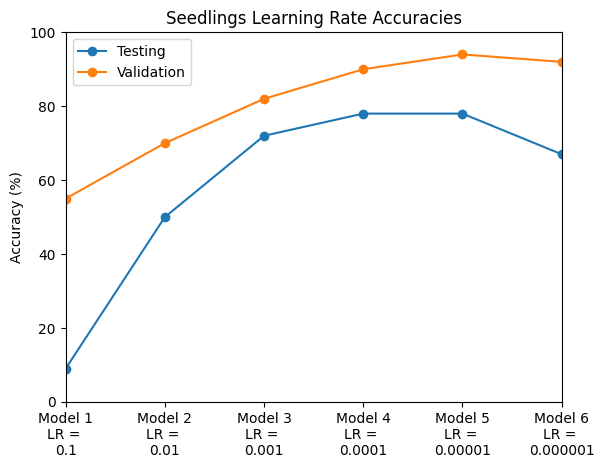

In [25]:
# Create plot for LR tests
x1 = [1, 2, 3, 4, 5, 6]
y1 = [9, 50, 72, 78, 78, 67]

# create x and y data for second line
x2 = [1, 2, 3, 4, 5, 6]
y2 = [55, 70, 82, 90, 94, 92]

# create plot
plt.plot(x1, y1, label='Testing', marker='o')
plt.plot(x2, y2, label='Validation', marker='o')

# set plot title and axis labels
plt.title('Seedlings Learning Rate Accuracies')
plt.ylabel('Accuracy (%)')

# set axis limits
plt.xlim(1, 5)
plt.ylim(0, 100)
plt.xticks(x1, ['Model 1\nLR = \n0.1', 'Model 2\nLR = \n0.01', 'Model 3\nLR = \n0.001', 'Model 4\nLR = \n0.0001', 'Model 5\nLR = \n0.00001', 'Model 6\nLR = \n0.000001'])

# add legend
plt.legend()
# plt.savefig('filename.png', dpi=300)

# show plot
plt.show()

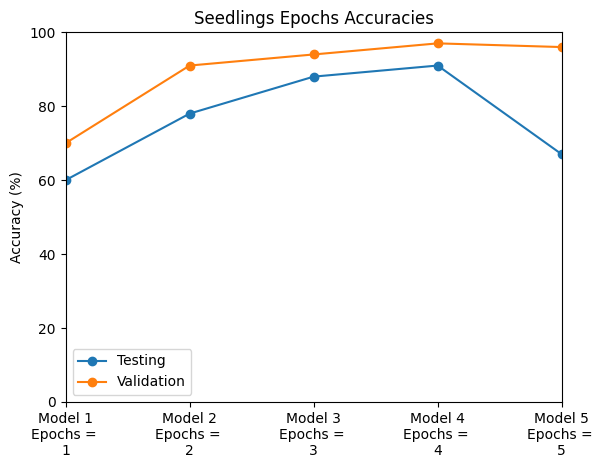

In [26]:
# Create plot for epochs tests
x1 = [1, 2, 3, 4, 5]
y1 = [60, 78, 88, 91, 67]

# create x and y data for second line
x2 = [1, 2, 3, 4, 5]
y2 = [70, 91, 94, 97, 96]

# create plot
plt.plot(x1, y1, label='Testing', marker='o')
plt.plot(x2, y2, label='Validation', marker='o')

# set plot title and axis labels
plt.title('Seedlings Epochs Accuracies')
plt.ylabel('Accuracy (%)')

# set axis limits
plt.xlim(1, 5)
plt.ylim(0, 100)
plt.xticks(x1, ['Model 1\nEpochs = \n1', 'Model 2\nEpochs = \n2', 'Model 3\nEpochs = \n3', 'Model 4\nEpochs = \n4', 'Model 5\nEpochs = \n5'])

# add legend
plt.legend()
# plt.savefig('filename.png', dpi=300)

# show plot
plt.show()